# 1. EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1. Аудит датасета

**Загрузим датасет**

In [3]:
df = pd.read_csv('E:/ML/housing-prices-ml/data/raw/train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Общая информация**

In [5]:
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 81 entries, Id to SalePrice
dtypes: float64(3), int64(35), str(43)
memory usage: 924.0 KB



Датасет содержит **1460 объектов** и **81 признак**

**Сформируем таблицу с признаками для аудита данных**

In [6]:
dataset_info = pd.DataFrame(index=df.columns)

dataset_info['Type'] = df.dtypes
dataset_info['Missing_count'] = df.isna().sum()
dataset_info['Missing_%'] = df.isna().mean() * 100
dataset_info['Unique_count'] = df.nunique()
dataset_info['Unique_%'] = df.nunique() / df.shape[0] * 100

pd.set_option('display.float_format', '{:.2f}'.format) # Форматрирование отображения числовых значений
dataset_info

,Type,Missing_count,Missing_%,Unique_count,Unique_%
Id,int64,0,0.00,1460,100.00
MSSubClass,int64,0,0.00,15,1.03
MSZoning,str,0,0.00,5,0.34
LotFrontage,float64,259,17.74,110,7.53
LotArea,int64,0,0.00,1073,73.49
...,...,...,...,...,...
MoSold,int64,0,0.00,12,0.82
YrSold,int64,0,0.00,5,0.34
SaleType,str,0,0.00,9,0.62
SaleCondition,str,0,0.00,6,0.41


**Рассмотрим количество пропусков**

In [7]:
dataset_info.sort_values('Missing_count', ascending=False).head(20)

,Type,Missing_count,Missing_%,Unique_count,Unique_%
PoolQC,str,1453,99.52,3,0.21
MiscFeature,str,1406,96.30,4,0.27
Alley,str,1369,93.77,2,0.14
Fence,str,1179,80.75,4,0.27
MasVnrType,str,872,59.73,3,0.21
FireplaceQu,str,690,47.26,5,0.34
LotFrontage,float64,259,17.74,110,7.53
GarageQual,str,81,5.55,5,0.34
GarageFinish,str,81,5.55,3,0.21
GarageType,str,81,5.55,6,0.41


В датасете 19 признаков с пропусками  

Наибольшее количество в признаках:  
* `PoolQC` (str) - Качество бассейна (99,53 %), 3 из которых уникаьные. NA соответствует отсутствию бассейна, на последующих этапах EDA целесообразно было бы выделить отдеьную категорию.  
* `MiscFeature` (str) - прочие особенности, невошедшие в другие категории. Ожидаемо большое количество отсутствующих значений (96,3 %). Несмотря на высокую долю пропусков, редкие категории могут иметь связь с SalePrice; влияние признака необходимо исследовать.
* `Alley` (str) - тип доступа к участку со стороны переулка (93,77 %). NA соответствует отсутствию доступа со стороны переулка, на последующих этапах EDA целесообразно было бы выделить отдеьную категорию.
* `Fence` (str) - качетво ограды (80,75). NA соответствует отсутствию ограды, на последующих этапах EDA целесообразно было бы выделить отдеьную категорию.
* `MasVnrType` (str) - тип облицовки каменной кладкой (59,73). NA соответствует отсутствию облицоввки, на последующих этапах EDA целесообразно было бы выделить отдеьную категорию.
* `FireplaceQu` (str) - качество камина (47,26 %). NA соответствует отсутствию камина, на последующих этапах EDA целесообразно было бы выделить отдеьную категорию.
* `LotFrontage` (float64)- протяженность участка вдоль улицы (17.74 %). Отсутсввие числового значения в этом признаке может информировать о типе объекта - квартира а не дом с участком. Однако это может быть реальный пропуск. На следующих этапах анализа можно выбрать стратегию заполнения в зависимости от формы распределения.  

У последующих признаков малое количество пропусков (< 10%):  
* `GarageQual`, `GarageFinish`, `GarageType`, `GarageCond` (str) - NA соответствует отсутсвтию гаража, выделим отдельную категорию  
* `GarageYrBlt` (folat64) - пропуск связан с отсутствием гаража. Требуется выбрать способ кодирования отсутствующего гаража; отдельно проверить, имеет ли смысл использовать `YearBuilt` или специальное значение.
* `BsmtFinType2`, `BsmtExposure`, `BsmtCond	`, `BsmtQual`, `BsmtFinType1` (str) - отсутствие значения соответствует отсутствию цокольного этажа, выделим отдельную категорию
* `MasVnrArea` (folat64) - всего 8 пропущенных значений, выберем стратегию заполнения на последующих этапах EDA
* `Electrical`(str) - имеется единственный пропуск, способ заполнения будет выбран на этапе preprocessing.

**Рассмотрим признаки с малым и большим количеством уникальных значений**

In [8]:
dataset_info[dataset_info['Unique_count'] < 4].sort_values('Unique_count').head(20)

,Type,Missing_count,Missing_%,Unique_count,Unique_%
Street,str,0,0.00,2,0.14
Alley,str,1369,93.77,2,0.14
Utilities,str,0,0.00,2,0.14
CentralAir,str,0,0.00,2,0.14
LandSlope,str,0,0.00,3,0.21
MasVnrType,str,872,59.73,3,0.21
BsmtHalfBath,int64,0,0.00,3,0.21
HalfBath,int64,0,0.00,3,0.21
GarageFinish,str,81,5.55,3,0.21
PavedDrive,str,0,0.00,3,0.21


Константные признаки отсутствуют

In [9]:
dataset_info.sort_values('Unique_count', ascending=False).head(30)

,Type,Missing_count,Missing_%,Unique_count,Unique_%
Id,int64,0,0.00,1460,100.00
LotArea,int64,0,0.00,1073,73.49
GrLivArea,int64,0,0.00,861,58.97
BsmtUnfSF,int64,0,0.00,780,53.42
1stFlrSF,int64,0,0.00,753,51.58
TotalBsmtSF,int64,0,0.00,721,49.38
SalePrice,int64,0,0.00,663,45.41
BsmtFinSF1,int64,0,0.00,637,43.63
GarageArea,int64,0,0.00,441,30.21
2ndFlrSF,int64,0,0.00,417,28.56


Признаки с большим количеством уникальных значений:  
* `Id` - Идентификатор, может быть исключен из рассмотрения


**Разделим признаки по типу**

In [10]:
num_features = df.select_dtypes(include='number').columns
cat_features = df.select_dtypes(include='str').columns

Проверим все ли признаки рассмотрены:

In [11]:
len(num_features) + len(cat_features) == df.shape[1]

True

**Рассмотрим числовые признаки на наличие категориальных**

Посмотрим на количество уникальных значений числовых признаков для того, чтобы выявить потенциально категориальные

In [12]:
dataset_info[(dataset_info['Unique_count'] < 20) & (dataset_info['Type'] == 'int64')].sort_values('Unique_count').head(20)

,Type,Missing_count,Missing_%,Unique_count,Unique_%
HalfBath,int64,0,0.00,3,0.21
BsmtHalfBath,int64,0,0.00,3,0.21
BsmtFullBath,int64,0,0.00,4,0.27
FullBath,int64,0,0.00,4,0.27
Fireplaces,int64,0,0.00,4,0.27
KitchenAbvGr,int64,0,0.00,4,0.27
YrSold,int64,0,0.00,5,0.34
GarageCars,int64,0,0.00,5,0.34
PoolArea,int64,0,0.00,8,0.55
BedroomAbvGr,int64,0,0.00,8,0.55


На основании описания данных и анализа уникальных значений были выделены признаки, требующие отдельного рассмотрения при выборе типа обработки.

`MSSubClass` является категориальным признаком, несмотря на числовой тип данных.

`OverallQual` и `OverallCond` являются порядковыми признаками: их значения имеют естественный порядок от низкого к высокому уровню качества/состояния, поэтому правильние их отнести к категориальным. Однако, обработка таких признаков через lavel encoding приведет к тому же резульату что и их числовое представление. Следовательно эти признаки можно оставить в числовых.

Ряд дискретных числовых признаков (`BsmtHalfBath`, `HalfBath`, `BsmtFullBath`, `FullBath`, `Fireplaces`, `KitchenAbvGr`, `GarageCars`, `BedroomAbvGr`, `TotRmsAbvGrd`) имеет небольшое количество уникальных значений. Эти признаки целесообразно дополнительно исследовать на этапе EDA.

`MoSold` и `YrSold` также требуют отдельного рассмотрения: это временные признаки, а не обычные категориальные переменные.

`Id` исключается как идентификатор объекта. `SalePrice` является целевой переменной и исключается из набора признаков X.

## 1.2. Анализ таргета

In [13]:
target = 'SalePrice'

**Числовая статистика**

In [14]:
df[target].describe()

count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64

**Анализ распределения**

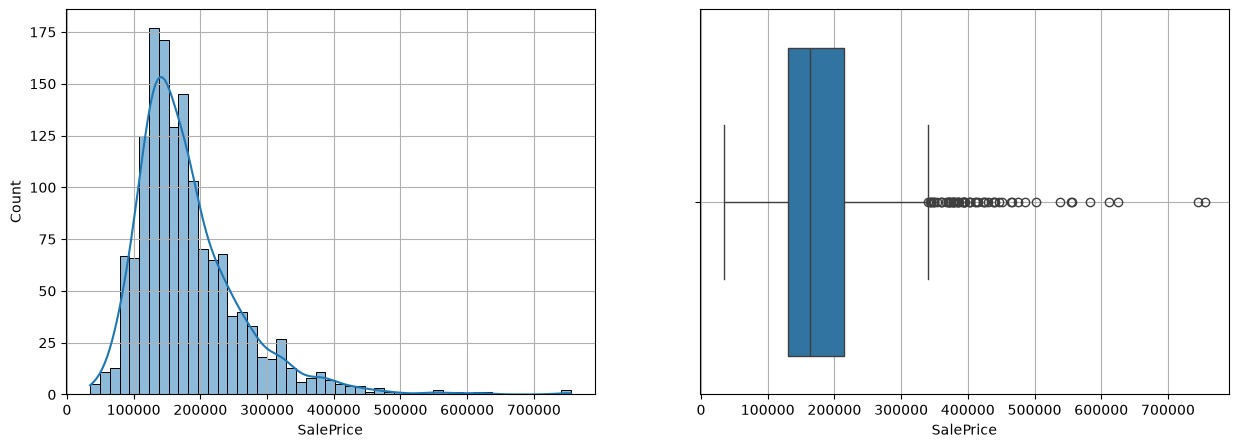

In [15]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(x=df[target], kde=True)
plt.grid()
plt.subplot(1, 2, 2)
sns.boxplot(x=df[target])
plt.grid()
plt.show()

При анализе значений целевой переменной `SalePrice` не обнаружено выбросов, все значения корректны.  
Распределение демонстрирует правостороннюю асимметрию - наличие длинного правого хвоста.  
Для использования линейных моделей целесообразно рассмотреть влияние логарифмирования значений  
Среднее: 180921.20  
Медиана: 163000.00  
Дисперсия: 79442.50  
Положительный эксцесс 

**Пологарифмируем целевую переменную**

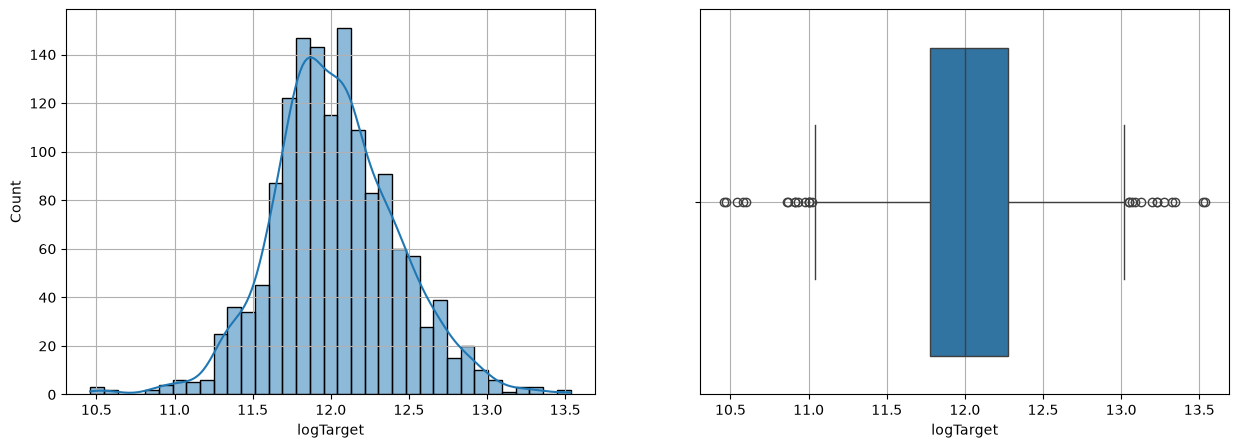

In [16]:
df['logTarget'] = np.log(df[target])

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(x=df['logTarget'], kde=True)
plt.grid()
plt.subplot(1, 2, 2)
sns.boxplot(x=df['logTarget'])
plt.grid()
plt.show()

После логарифмирования распределение целевой переменной стало симметричнее

## 1.3. Анализ признаков

Поскольку датасет объемный, вербальный анализ каждого из 80 признаков не представляется возможным.  
Для начала проверим наличие связи признаков с целевой переменной


**Рассмотрим матрицу корреляции для числовых признаков**

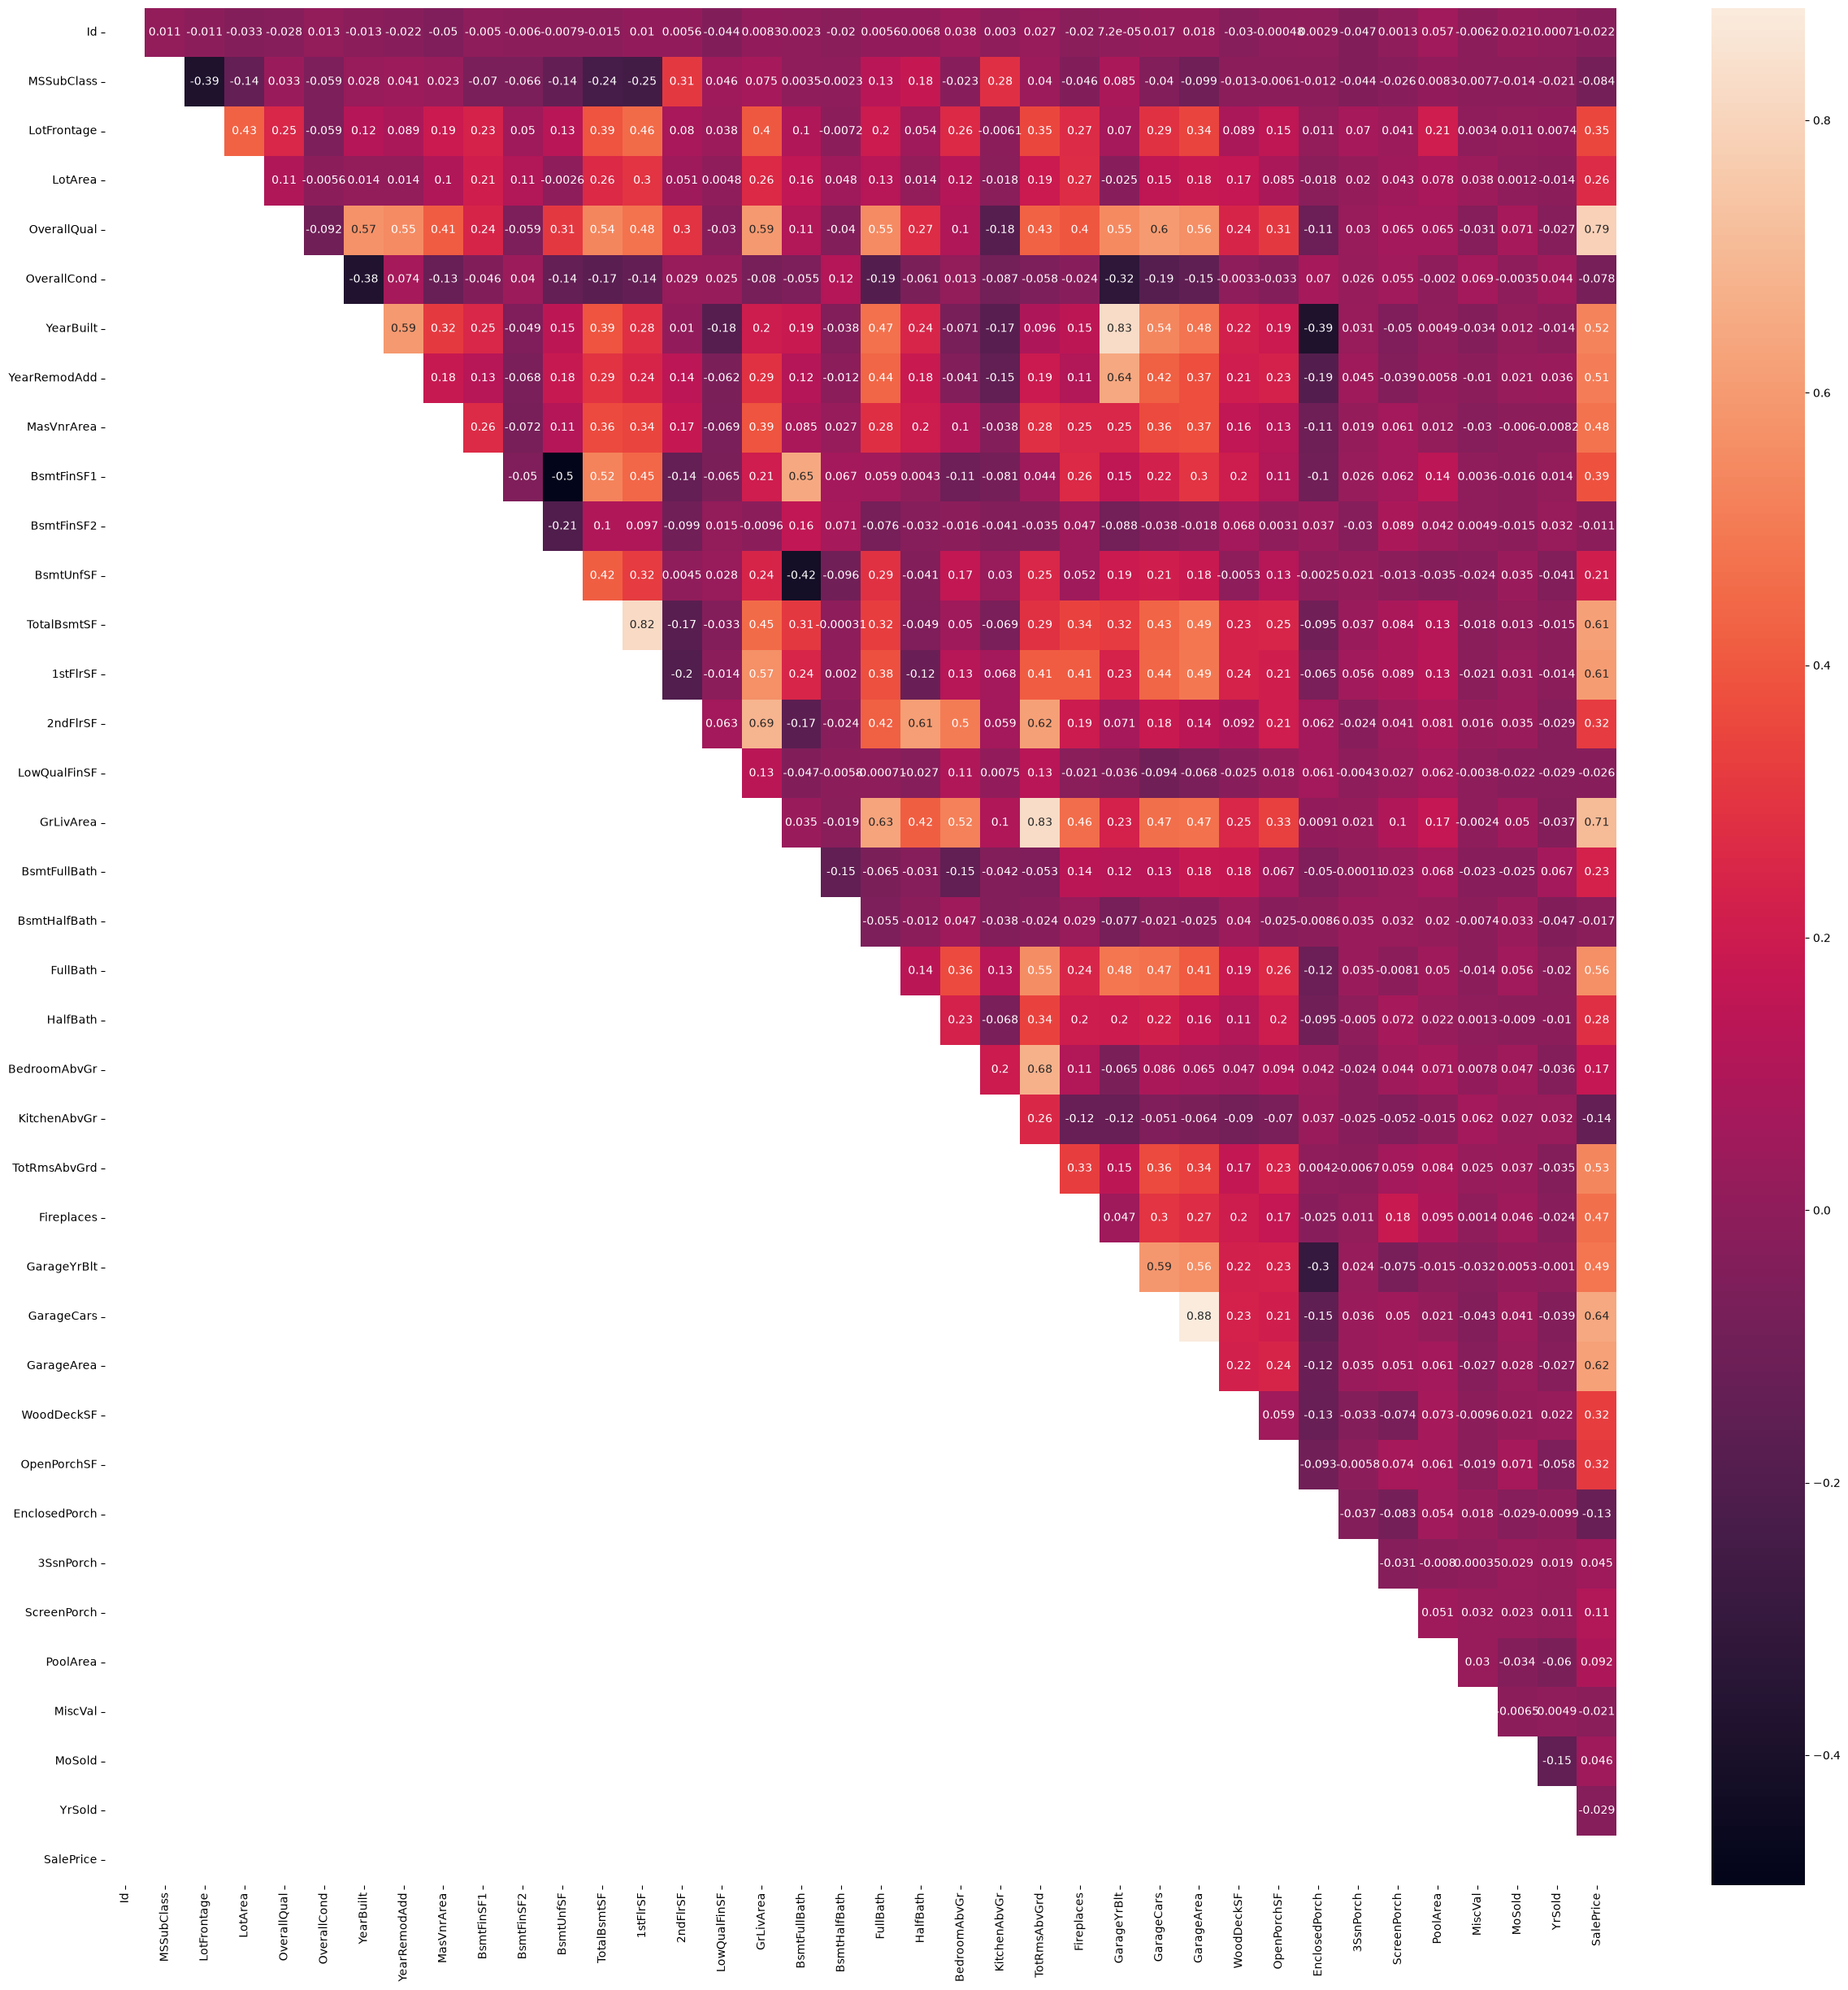

In [17]:
corr_table = df[num_features].corr()
mask = np.triu(np.ones(corr_table.shape), k=1).astype(bool)

plt.figure(figsize=(30, 30))
sns.heatmap(data=corr_table.where(mask), annot=True)
plt.show()

**Найдем значения с высокой корреляцией**

In [18]:
corr_table.where(mask).stack().sort_values(ascending=False).head(20)

GarageCars    GarageArea     0.88
YearBuilt     GarageYrBlt    0.83
GrLivArea     TotRmsAbvGrd   0.83
TotalBsmtSF   1stFlrSF       0.82
OverallQual   SalePrice      0.79
GrLivArea     SalePrice      0.71
2ndFlrSF      GrLivArea      0.69
BedroomAbvGr  TotRmsAbvGrd   0.68
BsmtFinSF1    BsmtFullBath   0.65
YearRemodAdd  GarageYrBlt    0.64
GarageCars    SalePrice      0.64
GrLivArea     FullBath       0.63
GarageArea    SalePrice      0.62
2ndFlrSF      TotRmsAbvGrd   0.62
TotalBsmtSF   SalePrice      0.61
2ndFlrSF      HalfBath       0.61
1stFlrSF      SalePrice      0.61
OverallQual   GarageCars     0.60
              GrLivArea      0.59
YearBuilt     YearRemodAdd   0.59
dtype: float64

Наибольшая линейная зависимость замечена между следующими признаками:
* `GarageCars`    `GarageArea`     0.88  
* `YearBuilt`     `GarageYrBlt`    0.83  
* `GrLivArea`     `TotRmsAbvGrd`   0.83  
* `TotalBsmtSF`   `1stFlrSF`       0.82  
* `2ndFlrSF`      `GrLivArea`      0.69  
* `BedroomAbvGr`  `TotRmsAbvGrd`   0.68  
* `BsmtFinSF1`    `BsmtFullBath`   0.65  
* `YearRemodAdd`  `GarageYrBlt`    0.64  
* `GrLivArea`     `FullBath`       0.63  
* `2ndFlrSF`      `TotRmsAbvGrd`   0.62  
* `2ndFlrSF`      `HalfBath`       0.61  
* `OverallQual`   `GarageCars`     0.60  


**Проанализируем корреляцию числовых признаков с таргетом**

In [ ]:
corr_table['SalePrice'].sort_values(key=lambda x: abs(x), ascending=False)

Признаки с наибольшей линейной зависимостью с `SalePrice`:
* `OverallQual` [0.79] - качество материалов и отделки (**порядковый признак**)
* `GrLivArea` [0.71] - площадь жилых помещений выше уровня земли
* `GarageCars` [0.64] - количество автомобилей, вмещаемых в гараж
* `GarageArea` [0.62] - площадь гаража
* `TotalBsmtSF` [0.61] - площаль подвала
* `1stFlrSF` [0.61] - площадь первого этажа
* `FullBath` [0.56] - количество ванных на цокольным этаже
* `TotRmsAbvGrd` [0.53] - общее количество комнат выше уровня земли (без учета ванных комнат)
* `YearBuilt` [0.52] - возраст постройки
* `YearRemodAdd` [0.51] - возраст ремонта
* `GarageYrBlt` [0.49] - возраст гаража
* `MasVnrArea` [0.48] - площадь облицовки каменной кладкой
* `Fireplaces` [0.47] - количество каминов


**Для категориальных признаков рассмотрим количество категорий и частоты**

In [ ]:
for feature in cat_features:
    df[feature] = df[feature].fillna('Missing')

    plt.figure()
    plt.title(feature)
    sns.countplot(data=df, x=feature)
    plt.show()

    cat_feature_stats = pd.DataFrame(index=df[feature].value_counts().index)
    cat_feature_stats['counts'] = df[feature].value_counts().values
    cat_feature_stats['%'] = df[feature].value_counts(normalize=True).values * 100
    #print(df[feature].value_counts(normalize=True))
    print(cat_feature_stats)


Большинство категориальных признаков обладают выраженным дисбаланссом классов.  
Отедльно можно выделить (преобладание одной из категорий более 90 %):
* `Street`
* `Alley`
* `Utilities`
* `LandSlope`
* `Condition2`
* `RoofMatl`
* `Heating`
* `CentralAir`
* `Electrical`
* `Functional`
* `GarageCond`
* `PoolQC`
* `MiscFeature`  
У признаков `Neighborhood`, `Condition1`, `Condition2`, `HouseStyle`, `Exterior1st`, `Exterior2nd`, `SaleType`  наблюдается большое клоичество категорий

**Рассмотрим связь с таргетом для категориальных признаков: сравним распредления `SalePrice` между категориями**

In [ ]:
for feature in cat_features:
    df[feature] = df[feature].fillna('Missing')

    plt.figure()
    sns.boxplot(data=df, x=feature, y=target)
    plt.show()
    
    print(f'\n{feature}')
    print(df.groupby(feature)[target].agg(['count', 'mean', 'std', 'median']))
    


Анализ связи категориальных признаков с таргетом показывает следующие особенности:
* `LotConfig`: агрегированные значения для категорий Mod и Sev схожи
* `GarageQual`: агрегированные значения для категорий Missing и Po схожи
* `GarageCond`: агрегированные значения для категорий Missing и Fa схожи
* `Fence`: агрегированные значения для категорий MnPrv и GdWo схожи


**Рассмотрим отдельно числовые признаки, которые несут катгориальный характер**

In [22]:
cat_num_features = ['MSSubClass', 'OverallQual', 'OverallCond', 'BsmtHalfBath', 'HalfBath', 'BsmtFullBath', 'FullBath', 'Fireplaces', 'KitchenAbvGr', 'GarageCars', 'BedroomAbvGr', 'TotRmsAbvGrd']

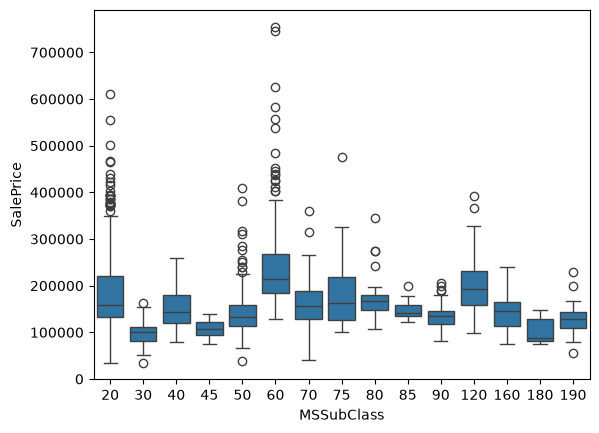


MSSubClass
            count      mean       std    median
MSSubClass                                     
20            536 185224.81  78782.19 159250.00
30             69  95829.72  24857.11  99900.00
40              4 156125.00  75747.80 142500.00
45             12 108591.67  20231.72 107500.00
50            144 143302.97  54851.98 132000.00
60            299 239948.50  86579.91 215200.00
70             60 166772.42  58206.55 156000.00
75             16 192437.50 100556.76 163500.00
80             58 169736.55  38197.81 166500.00
85             20 147810.00  19629.94 140750.00
90             52 133541.08  27833.25 135980.00
120            87 200779.08  58221.49 192000.00
160            63 138647.38  34587.54 146000.00
180            10 102300.00  29474.28  88500.00
190            30 129613.33  35439.10 128250.00


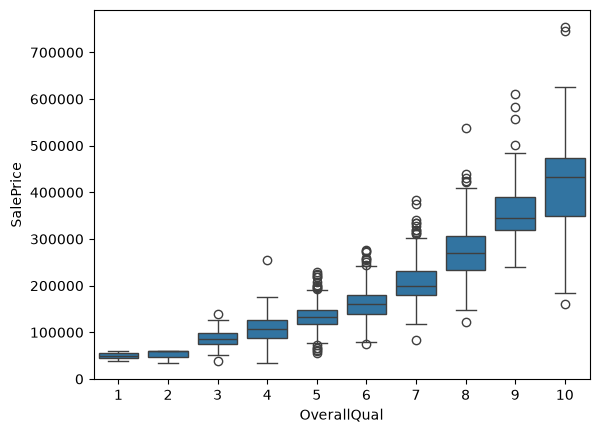


OverallQual
             count      mean       std    median
OverallQual                                     
1                2  50150.00  15344.22  50150.00
2                3  51770.33  14254.20  60000.00
3               20  87473.75  24688.57  86250.00
4              116 108420.66  29022.00 108000.00
5              397 133523.35  27107.33 133000.00
6              374 161603.03  36090.18 160000.00
7              319 207716.42  44466.26 200141.00
8              168 274735.54  63898.90 269750.00
9               43 367513.02  81278.17 345000.00
10              18 438588.39 159785.49 432390.00


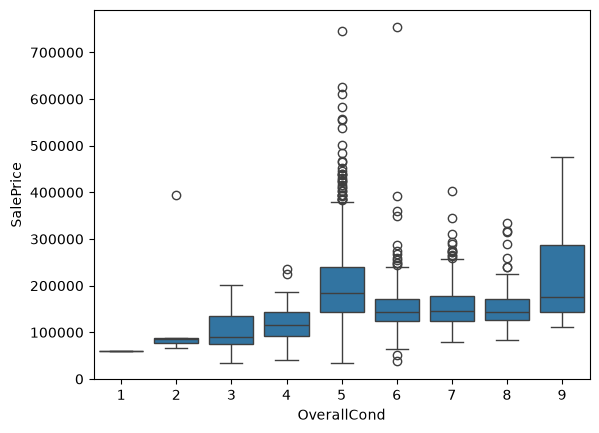


OverallCond
             count      mean       std    median
OverallCond                                     
1                1  61000.00       NaN  61000.00
2                5 141986.40 141342.81  85000.00
3               25 101929.40  44852.49  89500.00
4               57 120438.44  38922.53 115000.00
5              821 203146.91  85117.32 185000.00
6              252 153961.59  60737.97 142750.00
7              205 158145.49  53468.19 145000.00
8               72 155651.74  52375.14 142500.00
9               22 216004.55  96485.97 176200.00


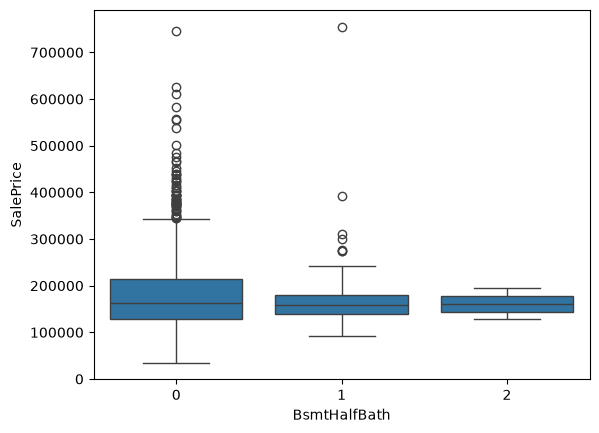


BsmtHalfBath
              count      mean      std    median
BsmtHalfBath                                    
0              1378 181230.33 79303.22 163250.00
1                80 176098.12 82901.00 159000.00
2                 2 160850.50 47164.73 160850.50


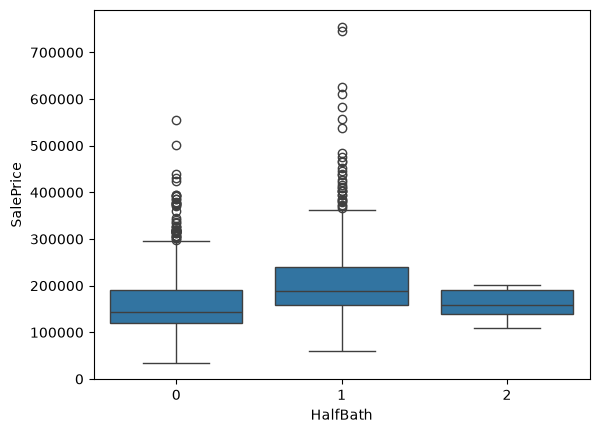


HalfBath
          count      mean      std    median
HalfBath                                    
0           913 162534.88 67450.34 143000.00
1           535 212721.96 88629.24 189000.00
2            12 162028.92 30315.71 159243.50


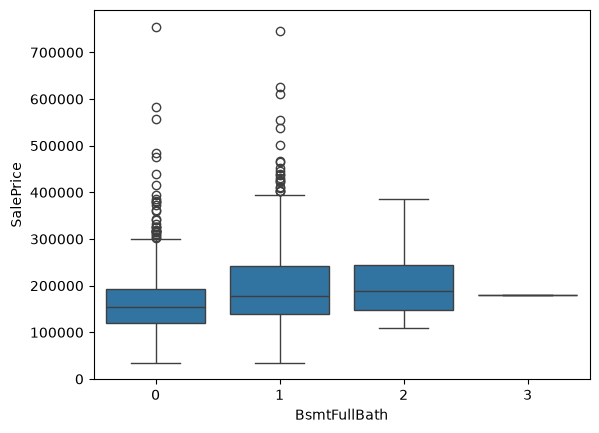


BsmtFullBath
              count      mean      std    median
BsmtFullBath                                    
0               856 165521.64 68137.82 154150.00
1               588 202522.92 88895.87 178800.00
2                15 213063.07 87308.20 188000.00
3                 1 179000.00      NaN 179000.00


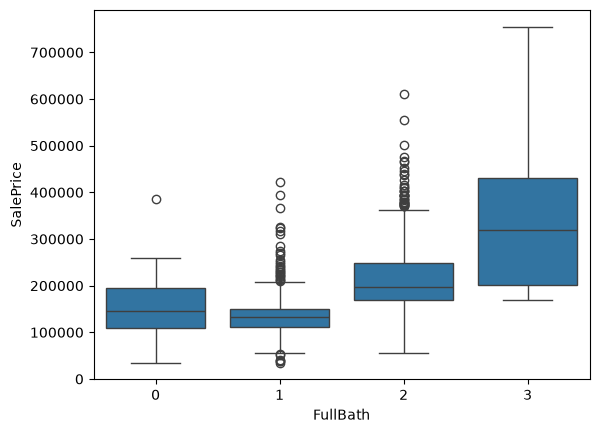


FullBath
          count      mean       std    median
FullBath                                     
0             9 165200.89 106083.81 145000.00
1           650 134751.44  41565.08 132375.00
2           768 213009.83  72446.81 196750.00
3            33 347822.91 165185.46 320000.00


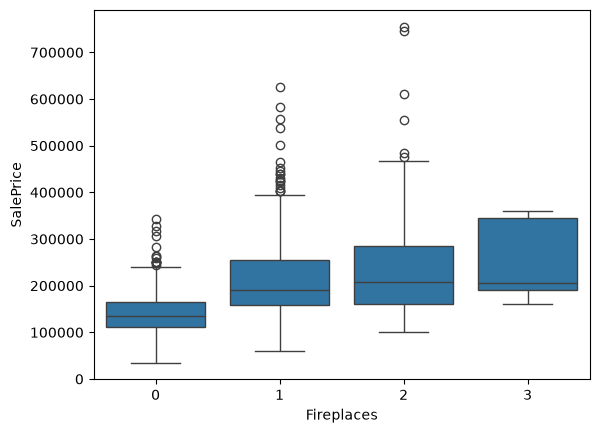


Fireplaces
            count      mean       std    median
Fireplaces                                     
0             690 141331.48  44389.79 135000.00
1             650 211843.91  79531.83 189975.00
2             115 240588.54 117451.80 206900.00
3               5 252000.00  93313.99 205000.00


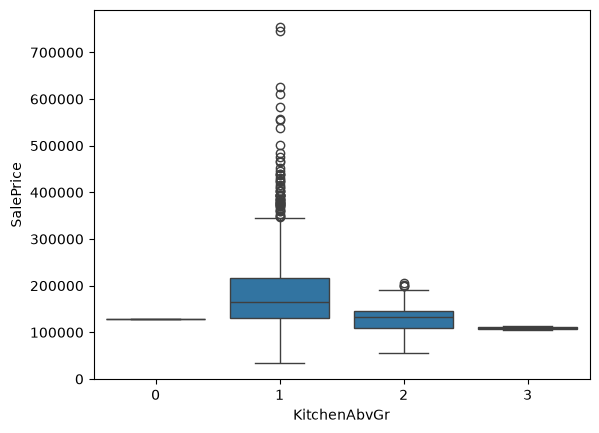


KitchenAbvGr
              count      mean      std    median
KitchenAbvGr                                    
0                 1 127500.00      NaN 127500.00
1              1392 183388.79 80265.34 165550.00
2                65 131096.15 31483.47 133900.00
3                 2 109500.00  4949.75 109500.00


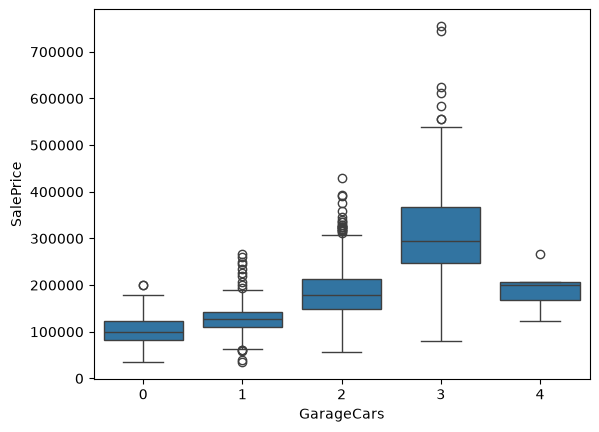


GarageCars
            count      mean       std    median
GarageCars                                     
0              81 103317.28  32815.02 100000.00
1             369 128116.69  30412.39 128000.00
2             824 183851.66  51617.14 177750.00
3             181 309636.12 106832.93 295000.00
4               5 192655.80  52621.84 200000.00


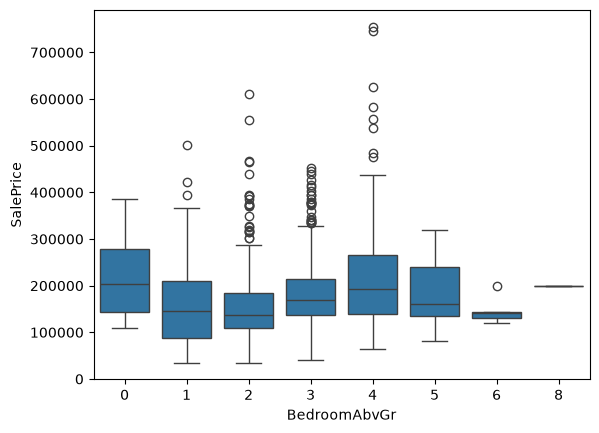


BedroomAbvGr
              count      mean       std    median
BedroomAbvGr                                     
0                 6 221493.17 106675.89 202500.00
1                50 173162.42 102975.07 145250.00
2               358 158197.66  78197.11 137250.00
3               804 181056.87  63793.92 169945.00
4               213 220421.25 109510.52 193500.00
5                21 180819.05  68472.48 161500.00
6                 7 143779.00  26455.38 141000.00
8                 1 200000.00       NaN 200000.00


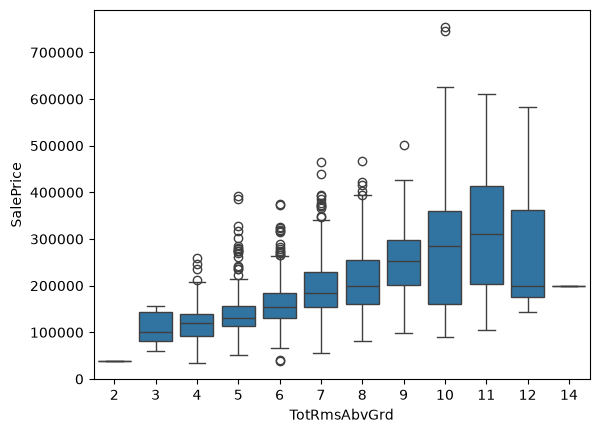


TotRmsAbvGrd
              count      mean       std    median
TotRmsAbvGrd                                     
2                 1  39300.00       NaN  39300.00
3                17 111217.65  33108.10 100000.00
4                97 122844.63  41661.81 120500.00
5               275 141550.75  49656.91 130250.00
6               402 161303.30  48707.37 155000.00
7               329 196666.78  64404.69 184100.00
8               187 213427.53  73985.72 200000.00
9                75 252988.17  83131.92 252000.00
10               47 296279.17 155027.99 285000.00
11               18 318022.00 148216.98 311738.50
12               11 280971.45 165510.92 200000.00
14                1 200000.00       NaN 200000.00


In [23]:
for feature in cat_num_features:
    df[feature] = df[feature].fillna('Missing')

    plt.figure()
    sns.boxplot(data=df, x=feature, y=target)
    plt.show()
    
    print(f'\n{feature}')
    print(df.groupby(feature)[target].agg(['count', 'mean', 'std', 'median']))
    

Следующие признаки демонстрируют сильную зависимость таргета от категории:
* `OverallQual`
* `GarageCars`
* `TotRmsAbvGrd`